In [3]:
import pandas as pd

df = pd.read_csv("../data/loan_data.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

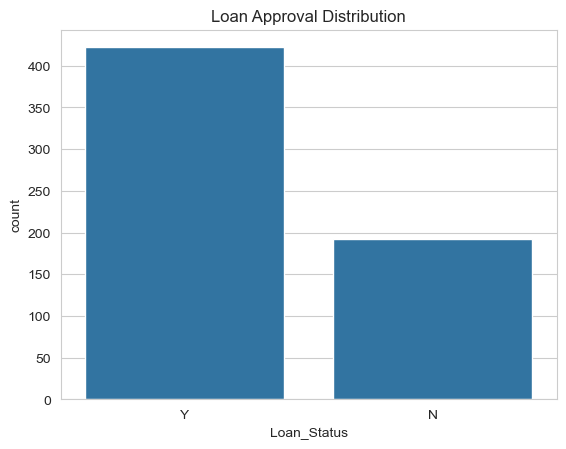

In [7]:
sns.countplot(x="Loan_Status", data=df)

plt.title("Loan Approval Distribution")
plt.show()

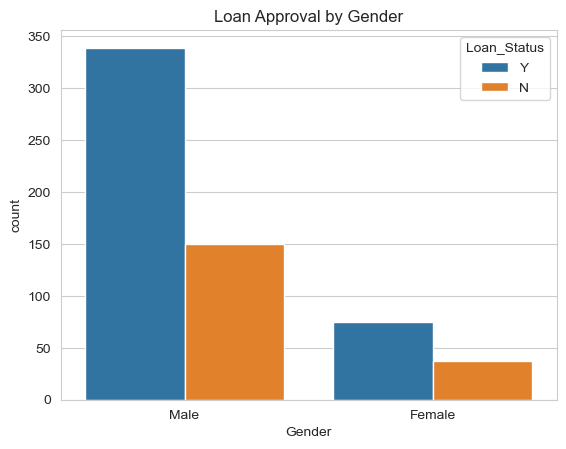

In [9]:
sns.countplot(x="Gender", hue="Loan_Status", data=df)

plt.title("Loan Approval by Gender")
plt.show()

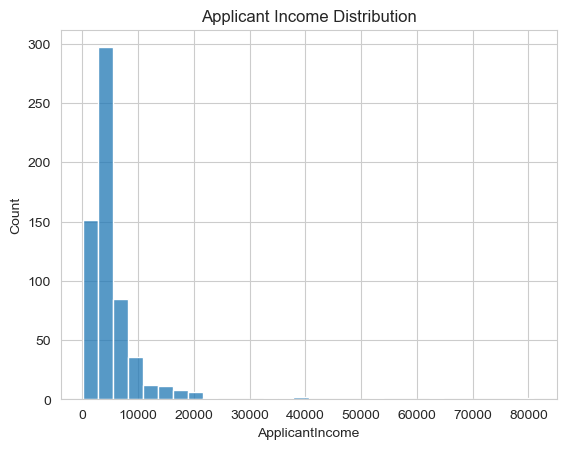

In [10]:
sns.histplot(df["ApplicantIncome"], bins=30)

plt.title("Applicant Income Distribution")
plt.show()

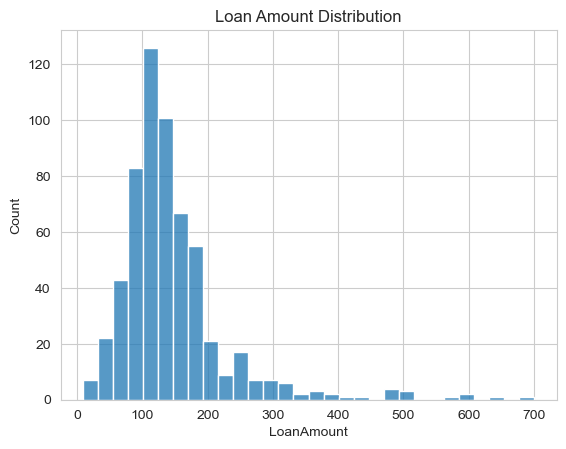

In [11]:
sns.histplot(df["LoanAmount"], bins=30)

plt.title("Loan Amount Distribution")
plt.show()

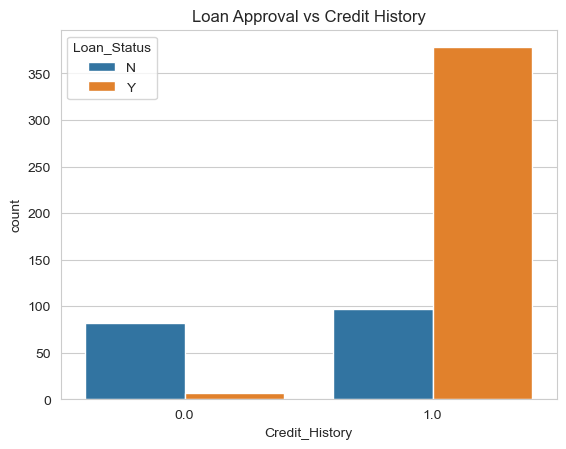

In [12]:
sns.countplot(x="Credit_History", hue="Loan_Status", data=df)

plt.title("Loan Approval vs Credit History")
plt.show()

In [13]:
df_temp = df.copy()

df_temp["Loan_Status"] = df_temp["Loan_Status"].map({"Y":1,"N":0})

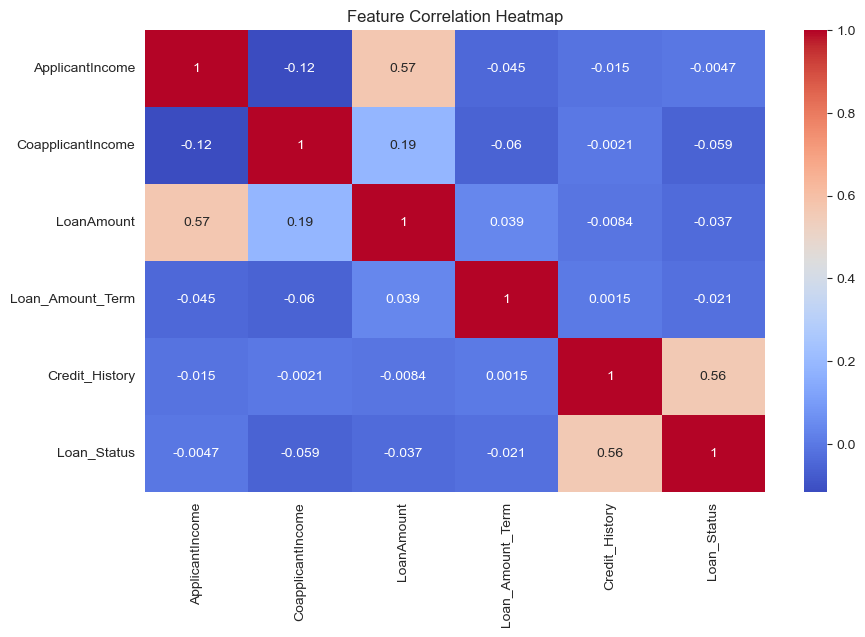

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df_temp.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

In [15]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [16]:
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)

df["Married"].fillna(df["Married"].mode()[0], inplace=True)

df["Dependents"].fillna(df["Dependents"].mode()[0], inplace=True)

df["Self_Employed"].fillna(df["Self_Employed"].mode()[0], inplace=True)

C:\Users\VAIBHAVI\AppData\Local\Temp\ipykernel_22112\3474402078.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)
C:\Users\VAIBHAVI\AppData\Local\Temp\ipykernel_22112\3474402078.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [17]:
df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)

df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median(), inplace=True)

C:\Users\VAIBHAVI\AppData\Local\Temp\ipykernel_22112\1443506492.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)
C:\Users\VAIBHAVI\AppData\Local\Temp\ipykernel_22112\1443506492.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [18]:
df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)

C:\Users\VAIBHAVI\AppData\Local\Temp\ipykernel_22112\895604288.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)


In [19]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [20]:
df["Loan_Status"] = df["Loan_Status"].map({"Y":1,"N":0})

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Married"] = le.fit_transform(df["Married"])
df["Education"] = le.fit_transform(df["Education"])
df["Self_Employed"] = le.fit_transform(df["Self_Employed"])
df["Property_Area"] = le.fit_transform(df["Property_Area"])

In [22]:
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

Step 5 — Feature Selection + Train/Test Split.

In [23]:
df.drop("Loan_ID", axis=1, inplace=True)

In [24]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [26]:
X_train.shape, X_test.shape

((491, 12), (123, 12))

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [28]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

ValueError: could not convert string to float: '3+'

In [29]:
X_train.dtypes

Gender                 int64
Married                int64
Dependents            object
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
TotalIncome          float64
dtype: object

In [30]:
df["Dependents"] = df["Dependents"].replace("3+", 3)
df["Dependents"] = df["Dependents"].astype(int)

In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Property_Area"] = le.fit_transform(df["Property_Area"])

In [32]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [34]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

C:\Users\VAIBHAVI\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [35]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [36]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [37]:
log_pred = log_model.predict(X_test)

knn_pred = knn_model.predict(X_test)

tree_pred = tree_model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

In [39]:
print("Logistic Regression Performance")

print("Accuracy:", accuracy_score(y_test, log_pred))

print("Precision:", precision_score(y_test, log_pred))

print("Recall:", recall_score(y_test, log_pred))

print("ROC-AUC:", roc_auc_score(y_test, log_pred))

Logistic Regression Performance
Accuracy: 0.7886178861788617
Precision: 0.7596153846153846
Recall: 0.9875
ROC-AUC: 0.7030523255813954


In [40]:
print("KNN Performance")

print("Accuracy:", accuracy_score(y_test, knn_pred))

print("Precision:", precision_score(y_test, knn_pred))

print("Recall:", recall_score(y_test, knn_pred))

print("ROC-AUC:", roc_auc_score(y_test, knn_pred))

KNN Performance
Accuracy: 0.5772357723577236
Precision: 0.6346153846153846
Recall: 0.825
ROC-AUC: 0.4706395348837209


In [41]:
print("Decision Tree Performance")

print("Accuracy:", accuracy_score(y_test, tree_pred))

print("Precision:", precision_score(y_test, tree_pred))

print("Recall:", recall_score(y_test, tree_pred))

print("ROC-AUC:", roc_auc_score(y_test, tree_pred))

Decision Tree Performance
Accuracy: 0.6991869918699187
Precision: 0.7529411764705882
Recall: 0.8
ROC-AUC: 0.6558139534883721


In [42]:
import pickle

In [43]:
pickle.dump(log_model, open("../models/loan_model.pkl", "wb"))

In [44]:
import streamlit as st
import pickle
import pandas as pd
import os

In [47]:
sample = X.iloc[0:1]

prediction = log_model.predict(sample)

print("Prediction:", prediction)

Prediction: [1]
